<h1 style="
  font-family: 'Glacial Indifference', sans-serif;
  font-size: 25px;
  text-align: center;
  background-color: #0F5444;
  color: white;
  border-radius: 50px 50px 0 0;
  line-height: 1.5;
  text-transform: uppercase;
  margin: 0;
  padding: 15px 20px;
">
  Diabetes Predictive Modeling: <br>
  A comparison between Logistic Regression and XGBoost
</h1>

# Objective

This analysis compares the performance of a traditional statistical modeling approach, Logistic Regression, with a modern tree-based method, XGBoost, for predicting diabetes risk and examine how lifestyle behaviors influence the likelihood of being diagnosed with diabetes. Logistic Regression is widely used in clinical and epidemiological research due to its interpretability and well-understood statistical properties, while XGBoost represents a more flexible, non-linear machine learning approach capable of capturing complex interactions in the data. By evaluating these two approaches under the same data, preprocessing, and validation framework, this study seeks to assess whether the increased modeling complexity of modern machine learning provides tangible benefits over a classical statistical baseline in a healthcare screening context.

# 1. Setup & Imports

In [55]:
# Core
import numpy as np
import pandas as pd
import joblib
from typing import Dict
from pathlib import Path
import matplotlib.pyplot as plt

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Statmodel
import statsmodels.api as sm

# XGBoost
from xgboost import XGBClassifier

# Optuna
import optuna

# SHAP
import shap

In [56]:
# Reproducibility
RANDOM_STATE = 42
N_SPLITS = 4
N_TRIALS = 30
TARGET = "diagnosed_diabetes"
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" /"processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"

In [57]:
processed_data = pd.read_csv(DATA_DIR / "diabetes_lifestyle_analysis.csv")

In [58]:
processed_data.head()

,diagnosed_diabetes,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,age,gender,ethnicity,education_level,income_level,employment_status
0,1,Never,0,215,5.7,7.9,7.9,58,Male,Asian,Highschool,Lower-Middle,Employed
1,0,Former,1,143,6.7,6.5,8.7,48,Female,White,Highschool,Middle,Employed
2,1,Never,1,57,6.4,10.0,8.1,60,Male,Hispanic,Highschool,Middle,Unemployed
3,1,Never,0,49,3.4,6.6,5.2,74,Female,Black,Highschool,Low,Retired
4,1,Never,1,109,7.2,7.4,5.0,46,Male,White,Graduate,Middle,Retired


# 2. Data preparation

In [59]:
X = processed_data.drop(columns=[TARGET])
y = processed_data[TARGET]

In [60]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

preprocessor_logreg = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_cols,
        ),
    ]
)


To ensure an unbiased assessment of model performance, the dataset is first split into training (80%) and test (20%) sets, with the test set held out and not used at any stage of model training or hyperparameter tuning. This unseen test set provides a realistic estimate of how each model would perform on new, real-world data.

Within the training set, 4-fold stratified cross-validation is employed to train and tune both models. Hyperparameters are optimised using Optuna with 30 trials per model, ensuring a fair comparison under equivalent validation conditions. No feature engineering is applied; models rely solely on the available variables to isolate the effect of the modeling approach itself.

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)


The primary evaluation metric used in this study is recall (sensitivity). In the context of diabetes screening, recall measures the proportion of true diabetes cases that are correctly identified by the model. Prioritising recall is clinically motivated, as false negatives—individuals with diabetes incorrectly classified as non-diabetic—represent missed cases that may delay diagnosis and treatment, potentially leading to adverse health outcomes.

While optimising for recall may increase the number of false positives, this trade-off is acceptable in a pre-diagnostic or screening setting, where positive predictions can be followed by more accurate and comprehensive clinical tests.

In [62]:
SCORING_METRIC = "recall"

# 3. Model training

## 3.1. Logistic Regression

### Equation

For a binary outcome such as `diagnosed_diabetes`, the logistic regression model can be written as:

**logit(P(Y = 1)) = β₀ + β₁·X₁ + β₂·X₂ + … + β<sub>k</sub>·X<sub>k</sub>**

Where:

- **Y = diagnosed_diabetes**
  - 0 = No
  - 1 = Yes
- **X<sub>1</sub>, X<sub>2</sub>, …, X<sub>k</sub>** are the predictor variables
  (e.g. age, gender, smoking status, BMI, physical activity, etc.)
- **β<sub>0</sub>** is the intercept
- **β<sub>i</sub>** represents the change in log-odds of diabetes associated with a one-unit increase in **X<sub>i</sub>**, holding other variables constant

In [63]:
X_train_transformed = preprocessor_logreg.fit_transform(X_train)

# Numeric features
num_features = numeric_cols

# Categorical features
cat_features = (
    preprocessor_logreg
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_cols)
)

feature_names = ["const"] + list(num_features) + list(cat_features)

### Model training

In [64]:
# Transform X_train
X_train_transformed = preprocessor_logreg.fit_transform(X_train)

# Convert to DataFrame with column names
X_train_df = pd.DataFrame(
    X_train_transformed,
    columns=feature_names[1:],  # exclude intercept for now
    index=X_train.index
)

# Add intercept
X_train_sm = sm.add_constant(X_train_df)

# Fit model
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

print(result.summary())


Optimization terminated successfully.
         Current function value: 0.656623
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:     diagnosed_diabetes   No. Observations:                80000
Model:                          Logit   Df Residuals:                    79975
Method:                           MLE   Df Model:                           24
Date:                Mon, 12 Jan 2026   Pseudo R-squ.:                 0.02437
Time:                        09:43:55   Log-Likelihood:                -52530.
converged:                       True   LL-Null:                       -53842.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                  0.4947      0.043    

### From Coefficients to Unit-Based Odds Ratios

Logistic regression coefficients (β) represent changes in the **log-odds of the outcome per one standard deviation (SD) increase** in a predictor when variables are standardized. To recover effects in the **original measurement units** (e.g., years, hours, minutes), coefficients must be rescaled.

For a numerical predictor `x` standardized as:

    x_std = (x - mean) / std

the change in log-odds associated with a **one-unit increase in the original variable** is:

    beta_unit = beta_sd / std

The corresponding **odds ratio (OR)** per one-unit increase in `x` is:

    OR_per_unit = exp(beta_sd / std)

**Interpretation of unit-based odds ratios:**

- **OR > 1** → each one-unit increase in `x` increases the odds of the outcome
- **OR < 1** → each one-unit increase in `x` decreases the odds
- **OR = 1** → no change in odds

This rescaling enables meaningful interpretation of standardized models in **real-world units**, while retaining the numerical stability benefits of standardization. Confidence intervals are transformed using the same rescaling approach.


In [65]:
# --- Extract coefficients and confidence intervals ---
params = result.params
conf = result.conf_int()
conf.columns = ["CI_lower", "CI_upper"]

# --- Get scaler statistics ---
scaler = preprocessor_logreg.named_transformers_["num"]
std_map = dict(zip(numeric_cols, scaler.scale_))

# --- Build per-unit odds ratios for numeric features ---
rows = []

for feature in numeric_cols:
    beta_sd = params[feature]
    ci_l_sd, ci_u_sd = conf.loc[feature]

    std = std_map[feature]

    rows.append({
        "feature": feature,
        "OR_per_unit": np.exp(beta_sd / std),
        "CI_lower": np.exp(ci_l_sd / std),
        "CI_upper": np.exp(ci_u_sd / std)
    })

per_unit_or_table = pd.DataFrame(rows).sort_values(
    by="OR_per_unit", ascending=False
)

print(per_unit_or_table)

                              feature  OR_per_unit  CI_lower  CI_upper
5                                 age     1.019179  1.018221  1.020137
4           screen_time_hours_per_day     1.014447  1.008552  1.020377
0        alcohol_consumption_per_week     1.000811  0.990718  1.011006
3                 sleep_hours_per_day     0.998583  0.985553  1.011785
1  physical_activity_minutes_per_week     0.997523  0.997354  0.997692
2                          diet_score     0.949267  0.941620  0.956976


### Model inference

**1. Model Overview**

- **Dependent variable:** `diagnosed_diabetes` (binary: yes/no)
- **Sample size:** 80,000 observations
- **Model fit:**
  - **Pseudo R² = 0.024** → Typical for logistic regression on large epidemiological datasets; does not imply the model is insignificant.
  - **Likelihood Ratio Test p-value < 0.001** → The model is statistically significant overall, confirming that predictors jointly improve model fit.

**2. Key Significant Predictors (p < 0.05, CI not included 1)**

- Positive association with diabetes (OR > 1):
    - **Age (OR = 1.0192)**: Each additional year increases the odds of diabetes by ~1.92%.
    - **Screen time (OR = 1.0144)**: Each additional hour per day increases odds by ~1.44%.
- Negative association with diabetes (OR < 1):
    - **Physical activity (OR = 0.9975):** Each additional minute of physical activity per week reduce the odds of diabetes by 0.25%.
    - **Diet score (OR = 0.9492):** A healthier diet reduces odds by ~5.08% per unit increase.
    - **Employment status – Retired (OR = 0.96, p = 0.034):** Slightly reduces odds (~4%), variable is significant at 5% threshold but not at 1%.

**3. Non-significant Predictors (p ≥ 0.05, 95% CI includes 1)**
- **Lifestyle factors:** Alcohol consumption, sleep hours, smoking status, gender
- **Socioeconomic factors:** Education and income levels
- **Ethnicity:** Black, Hispanic, White, Other

> Interpretation: These variables do not show a statistically significant independent effect on diabetes after adjusting for all other factors.

**4. Practical Takeaways**

- **Modifiable risk factors** such as physical activity, diet, and screen time are associated with meaningful changes in diabetes risk, supporting lifestyle interventions.
- **Non-modifiable factors** like age remain important predictors, highlighting the need for targeted screening in older adults.
- **Most demographic variables** (gender, ethnicity, education, income) were not independently associated with diabetes, indicating that their effects may be largely explained by lifestyle factors.


### Reports and final model saving

Finally, the outputs are saved to support post-training evaluation and analysis:

In [66]:
# Save model summary to text file
with open(REPORTS_DIR / "logistic_regression_summary.txt", "w") as f:
    f.write(result.summary().as_text())
# Save odds ratios to text file
with open(REPORTS_DIR / "logistic_regression_odds_ratios.txt", "w") as f:
    f.write(odds_ratios.to_string())
# Save model
result.save(MODEL_DIR / "LR_v1.pkl")

## 3.2. XGBoost model

### Main concepts

**XGBoost and Hyperparameter Optimization**

XGBoost is a gradient boosting algorithm that builds an ensemble of decision trees sequentially, where each tree attempts to correct the errors of the previous ones. Its main hyperparameters include:
- **`n_estimators`**: number of trees in the ensemble,
- **`max_depth`**: maximum depth of each tree (controls model complexity),
- **`learning_rate`**: step size for each boosting iteration (lower values improve stability but require more trees),
- **`subsample`** and **`colsample_bytree`**: fractions of samples and features used to grow each tree (help prevent overfitting).

Optuna is used to automatically find the combination of these hyperparameters that **maximizes a chosen metric** (in this case, recall) through **trial-and-error optimization**. Each trial evaluates a different set of parameters using cross-validation, and Optuna employs efficient strategies to explore the parameter space and suggest new promising values for the next trial, ultimately identifying the best-performing configuration.


### Model training

In [67]:
# --- Optuna objective for XGBoost ---
def objective_xgb(trial: optuna.Trial) -> float:
    # Simple parameter search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
    }

    model = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("clf", XGBClassifier(**params)),
        ]
    )

    # Use recall as metric
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=SCORING_METRIC,
        n_jobs=-1,
    )

    return scores.mean()

# --- Run Optuna study (simpler, 30 trials) ---
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)

[I 2026-01-12 09:43:55,457] A new study created in memory with name: no-name-5f628617-a02c-4725-aa66-b442aedef614
[I 2026-01-12 09:44:00,422] Trial 0 finished with value: 0.5772531582492986 and parameters: {'n_estimators': 228, 'max_depth': 3, 'learning_rate': 0.039792779807831795, 'subsample': 0.9064401262769534, 'colsample_bytree': 0.8433945391117765}. Best is trial 0 with value: 0.5772531582492986.
[I 2026-01-12 09:44:04,894] Trial 1 finished with value: 0.5800032485346001 and parameters: {'n_estimators': 226, 'max_depth': 5, 'learning_rate': 0.15145976015434612, 'subsample': 0.88523645056714, 'colsample_bytree': 0.9046947959637534}. Best is trial 1 with value: 0.5800032485346001.
[I 2026-01-12 09:44:06,716] Trial 2 finished with value: 0.5760239672750507 and parameters: {'n_estimators': 133, 'max_depth': 5, 'learning_rate': 0.05606387945532992, 'subsample': 0.9269706420831083, 'colsample_bytree': 0.9650536256437681}. Best is trial 1 with value: 0.5800032485346001.
[I 2026-01-12 09:

In [68]:
best_xgb_params = study_xgb.best_params
print("Best XGBoost parameters:", best_xgb_params)

Best XGBoost parameters: {'n_estimators': 272, 'max_depth': 6, 'learning_rate': 0.11895421991145698, 'subsample': 0.8355318732312156, 'colsample_bytree': 0.9434637067461953}


For XGBoost, we use the best hyperparameters identified through optimization to fit the final model:

In [ ]:
# --- Create the final XGBoost pipeline ---
final_xgb = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "clf",
            XGBClassifier(
                **best_xgb_params,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            ),
        ),
    ]
)

final_xgb.fit(X_train, y_train)

### Model inference - XGBoost interpretability

To improve interpretability of the XGBoost model, we use **SHAP (SHapley Additive exPlanations)**, a model-agnostic framework grounded in cooperative game theory. SHAP explains individual predictions by decomposing the model output into additive contributions from each feature.

Formally, the model prediction can be written as:

`f(x) = φ₀ + Σᵢ φᵢ`

where `φ₀` is the baseline (expected model output), `φᵢ` is the SHAP value of feature *i*, and `Σᵢ φᵢ` represents the total contribution of all features.

In [70]:
# Extract fitted components
preprocessor = final_xgb.named_steps["preprocess"]
xgb_model = final_xgb.named_steps["clf"]

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# Numeric features
num_features = numeric_cols

# Categorical features (after one-hot encoding)
cat_features = preprocessor.named_transformers_["cat"] \
    .get_feature_names_out(categorical_cols)

# Combine
feature_names = np.concatenate([num_features, cat_features])

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)


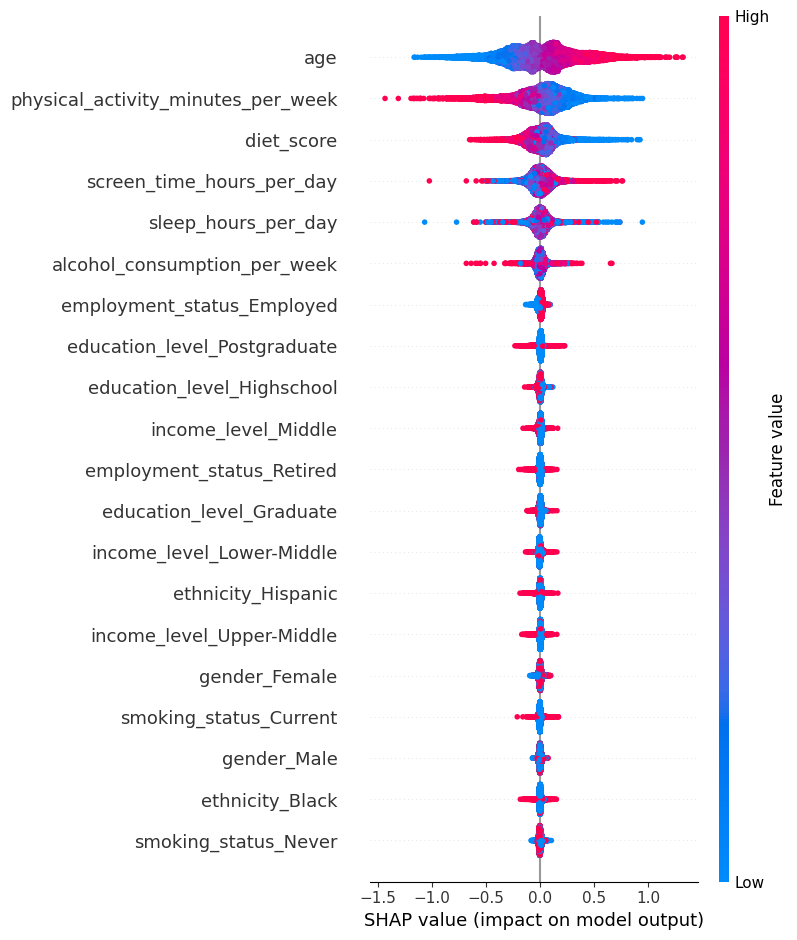

In [71]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    # max_display=10
)


This SHAP summary plot shows the global importance and direction of feature effects in the XGBoost model. Features are ranked by their overall contribution to predictions, with SHAP values to the right increasing the predicted diabetes risk and values to the left decreasing it.
- Age is the most influential factor, with higher age consistently increasing predicted risk.
- Physical activity and diet score exhibit strong protective effects, where higher values reduce diabetes risk, highlighting the importance of modifiable lifestyle behaviours.
- Screen time tends to increase risk, while longer sleep duration is generally associated with lower predicted risk, although with more variability.
- Alcohol consumption shows a smaller positive association with risk.
- Socio-demographic variables such as education, employment, smoking, and income contribute less overall, indicating that the model’s predictions are driven primarily by age and lifestyle-related factors.

These relationships largely mirror the findings from the logistic regression model, indicating that XGBoost captures similar underlying associations while maintaining a high level of interpretability. Although the exact marginal effect of a single feature on the outcome cannot be expressed as a fixed coefficient, SHAP values provide transparent insight into how each feature contributes to changes in the predicted diabetes risk.

### Reports and final model saving

In [72]:
# Save the figure
plt.savefig(REPORTS_DIR / "shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.close()  # Close the figure to free memory

In [73]:
# Save the final XGBoost pipeline
joblib.dump(final_xgb, MODEL_DIR / "XGB_final.pkl")

['E:\\Github\\diabetes_project\\models\\XGB_final.pkl']

# 4. Model evaluation

Final evaluation was conducted on the held-out test set with a classification threshold of 0.5. Performance was assessed using the confusion matrix and recall, defined as:

- **True Positives (TP):** correctly identified diabetes cases
- **False Negatives (FN):** missed cases, representing the most critical error
- **False Positives (FP):** individuals flagged as at risk for confirmatory testing
- **True Negatives (TN):** correctly identified non-diabetic individuals
- **Recall = TP / (TP + FN):** measures the proportion of actual diabetes cases correctly identified; higher recall is crucial in screening, where missing cases (FN) is more harmful than over-identifying at-risk individuals (FP).

In this context, models that minimize false negatives, even at the cost of additional false positives, are preferable to reduce undiagnosed diabetes while ensuring patient follow-up.

In [ ]:
# For Logistic Regression, we rebuild the model within a scikit-learn pipeline to obtain the final fitted version.
# --- Create the final sklearn Logistic Regression pipeline ---
final_logreg = Pipeline(
    steps=[
        ("preprocess", preprocessor_logreg),  # use the same preprocessor
        ("clf", LogisticRegression(
            C=np.inf, # no regularization
            solver="lbfgs",
            class_weight="balanced",  # handles class imbalance, in our case 60:40 ratio
            random_state=RANDOM_STATE
        )),
    ]
)

# Fit the model
final_logreg.fit(X_train, y_train)


In [75]:
def evaluate(model, X_test, y_test) -> Dict:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Recall": recall_score(y_test, y_pred),
    }


In [76]:
logreg_results = evaluate(final_logreg, X_test, y_test)
xgb_results = evaluate(final_xgb, X_test, y_test)

pd.DataFrame([logreg_results, xgb_results], index=["Logistic Regression", "XGBoost"])

,Recall
Logistic Regression,0.581667
XGBoost,0.587333


XGBoost achieves a slightly higher recall than Logistic Regression, suggesting it identifies a marginally larger proportion of true diabetes cases. Overall, both models perform comparably, though XGBoost’s ability to capture non-linear relationships may offer a small advantage in detecting cases that Logistic Regression could miss. We further examine their confusion matrices to understand the source of this difference.

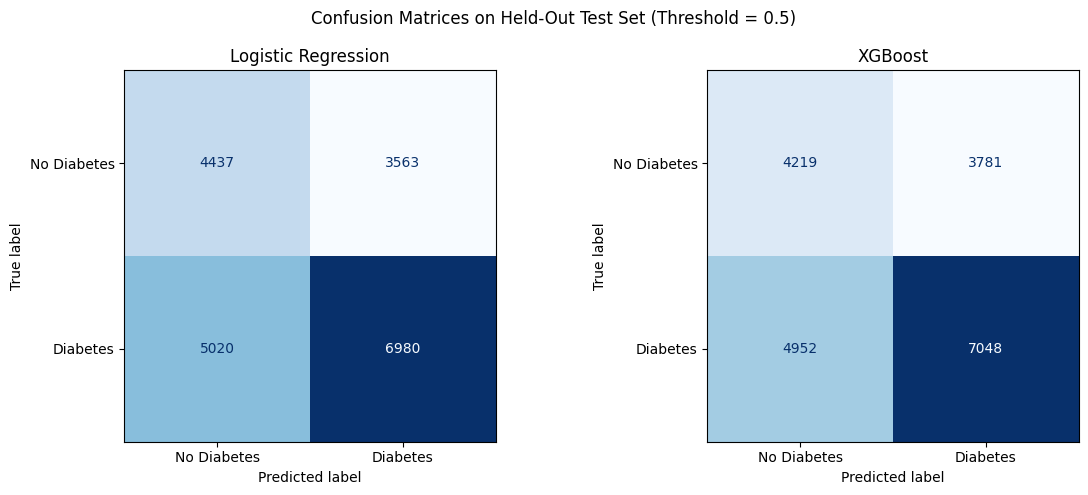

In [77]:
# ---------- Logistic Regression ----------
y_test_proba_logreg = final_logreg.predict_proba(X_test)[:, 1]
y_pred_logreg = (y_test_proba_logreg >= 0.5).astype(int)
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

# ---------- XGBoost ----------
y_test_proba_xgb = final_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_test_proba_xgb >= 0.5).astype(int)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# ---------- Plot side-by-side ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
disp_logreg = ConfusionMatrixDisplay(
    confusion_matrix=cm_logreg,
    display_labels=["No Diabetes", "Diabetes"]
)
disp_logreg.plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)
axes[0].set_title("Logistic Regression")
axes[0].grid(False)

# XGBoost
disp_xgb = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["No Diabetes", "Diabetes"]
)
disp_xgb.plot(
    ax=axes[1],
    cmap="Blues",
    colorbar=False
)
axes[1].set_title("XGBoost")
axes[1].grid(False)

plt.suptitle("Confusion Matrices on Held-Out Test Set (Threshold = 0.5)")
plt.tight_layout()
plt.show()


The confusion matrices on the held-out test set reveal differences in error profiles between Logistic Regression and XGBoost at a 0.50 classification threshold.
- Compared with Logistic Regression, XGBoost reduced the number of missed diabetes cases (FN) and increased correctly identified cases (TP), resulting in more at-risk individuals being referred for further diagnostic testing. This improvement comes at the cost of a higher false positives (FP) and fewer true negatives (TN), a trade-off that is clinically acceptable in screening or pre-diagnostic contexts, as FP can be addressed through follow-up assessments while FN represent missed opportunities for early intervention.
- Overall, Logistic Regression remains a strong and interpretable baseline, but XGBoost demonstrates superior performance for predicting task and where different metrics rather than accuracy is being usedrecall-focused screening by minimizing missed diabetes cases.

<h1 style="
  font-family: 'Glacial Indifference', sans-serif;
  font-size: 25px;
  text-align: center;
  background-color: #0F5444;
  color: white;
  border-radius: 0 0 50px 50px;
  line-height: 1.5;
  text-transform: uppercase;
  margin: 0;
  padding: 15px 20px;
">
  The End
</h1>